# 03 · LightGBM forecast, rolling-origin backtest, risk scoring (M3)

Project FORESIGHT · NorthBay Living · Zidio Development Data Science internship · Eswar Mahalingam

In [1]:
import sys, json, pandas as pd, numpy as np, matplotlib.pyplot as plt
from pathlib import Path
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT / 'src'))
pd.set_option('display.width', 160); pd.set_option('display.max_columns', 30)
from IPython.display import Image, display

## 1. Train + backtest + forecast
`src/forecast.py` retrains at 6 rolling origins (4 weeks apart), scores the next 8 weeks each time, then fits the final model at the forecast origin (2025-11-30).

In [2]:
import forecast
forecast.main()

fold 1 origin 2025-05-18  WAPE model=0.080  naive=0.100


fold 2 origin 2025-06-15  WAPE model=0.085  naive=0.110


fold 3 origin 2025-07-13  WAPE model=0.094  naive=0.117


fold 4 origin 2025-08-10  WAPE model=0.092  naive=0.121


fold 5 origin 2025-09-07  WAPE model=0.090  naive=0.114


fold 6 origin 2025-10-05  WAPE model=0.087  naive=0.110



ROLLING-ORIGIN BACKTEST (6 folds × 8 weeks, 2400 sku-weeks)
  WAPE  model 0.088  vs  seasonal-naive 0.112  → 21.5% better
  Bias  model +0.003  vs  naive +0.003
  Model beats naive on 49/50 SKUs
  Dec-2025 holdout: {'weeks': 4, 'wape_model': 0.09255749765157867, 'wape_naive': 0.12418150488225158, 'bias_model': -0.0014781182834358547, 'coverage80': 0.795}


In [3]:
met = json.loads((ROOT/'outputs/backtest_metrics.json').read_text())
pd.DataFrame(met['by_fold'])

,fold,origin,wape_model,wape_naive
0,1,2025-05-18,0.079780,0.100396
1,2,2025-06-15,0.084794,0.109654
2,3,2025-07-13,0.093826,0.116899
3,4,2025-08-10,0.092071,0.121312
4,5,2025-09-07,0.089865,0.113703
5,6,2025-10-05,0.087042,0.110303


In [4]:
pd.DataFrame(met['by_horizon'])

,h,wape_model,wape_naive
0,1,0.080160,0.106596
1,2,0.086238,0.105970
2,3,0.087670,0.109482
3,4,0.091767,0.116685
4,5,0.087095,0.110936
5,6,0.086112,0.110829
6,7,0.086318,0.112301
7,8,0.095703,0.120702


In [5]:
pd.DataFrame(met['by_category'])

,category,wape_model,wape_naive
0,Furniture,0.096741,0.121158
1,Home Decor,0.083201,0.103747
2,Kitchen,0.087537,0.114954
3,Lighting,0.083930,0.107872
4,Storage,0.089544,0.114605


## 2. Honest verdict
The model beats the seasonal-naive baseline on every fold, every horizon and every category, and on the true December-2025 holdout the model had never seen. The 80% interval covers ~80% of holdout actuals, so the uncertainty is calibrated.

In [6]:
print(json.dumps(met['overall'], indent=2)); print('holdout:', met['holdout_dec2025'])

{
  "wape_model": 0.08753725568440088,
  "wape_naive": 0.11155856160935741,
  "mape_model": 0.10845014722293646,
  "mape_naive": 0.1382257653464382,
  "bias_model": 0.0032356259828543537,
  "bias_naive": 0.003075205242492747,
  "improvement_pct": 21.532462931058138,
  "model_wins": true
}
holdout: {'weeks': 4, 'wape_model': 0.09255749765157867, 'wape_naive': 0.12418150488225158, 'bias_model': -0.0014781182834358547, 'coverage80': 0.795}


## 3. Risk scoring & decisioning grid

In [7]:
import risk
risk.main()

quadrant
Healthy             34
Markdown / clear     8
Reorder now          8
Sales at risk  ₹4,788,726   Locked capital ₹14,766,060
sku_id         quadrant  stockout_score  overstock_score  on_hand  on_order  demand_8w  weeks_of_cover  sales_at_risk_inr  locked_capital_inr  reorder_qty
SKU020 Markdown / clear            0.00            0.913     1002       353      708.3            15.3                0.0           4332746.0            0
SKU006 Markdown / clear            0.00            1.000      359       485      353.4            19.1                0.0           2954425.0            0
SKU012      Reorder now            1.00            0.000       47        60     1371.8             0.6          2054665.0                 0.0          919
SKU011 Markdown / clear            0.00            1.000      753       269      140.3            58.3                0.0           1515199.0            0
SKU036 Markdown / clear            0.00            1.000      383       135      255.7      

{
  "peak_month": 3,
  "trough_month": 10,
  "peak_vs_trough_pct": 52.25607404550714,
  "weekend_lift_pct": 24.862329465272804,
  "promo_lift_pct": 38.12067723804762,
  "holiday_effect_pct": -13.287805801801367,
  "top10_revenue_share_pct": 47.729850468707774,
  "bottom10_revenue_share_pct": 3.9861411183828444,
  "dead_stock_candidates": [
    "SKU028",
    "SKU048",
    "SKU010",
    "SKU050",
    "SKU011"
  ],
  "skus": 50,
  "n_negative_margin": 16,
  "negative_margin_revenue_share_pct": 16.69237227354079,
  "top_sku": "SKU026"
}


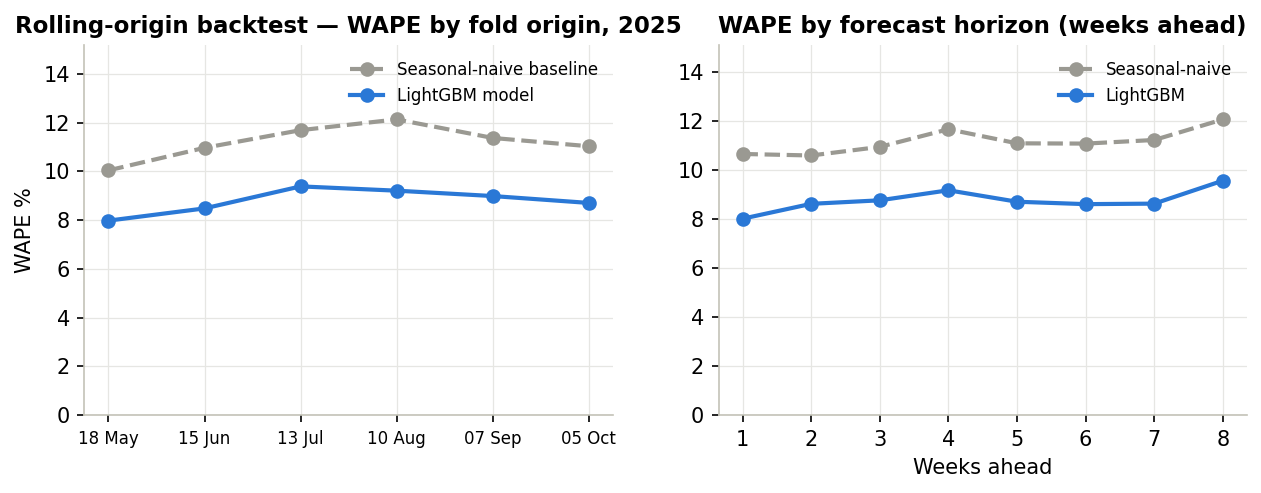

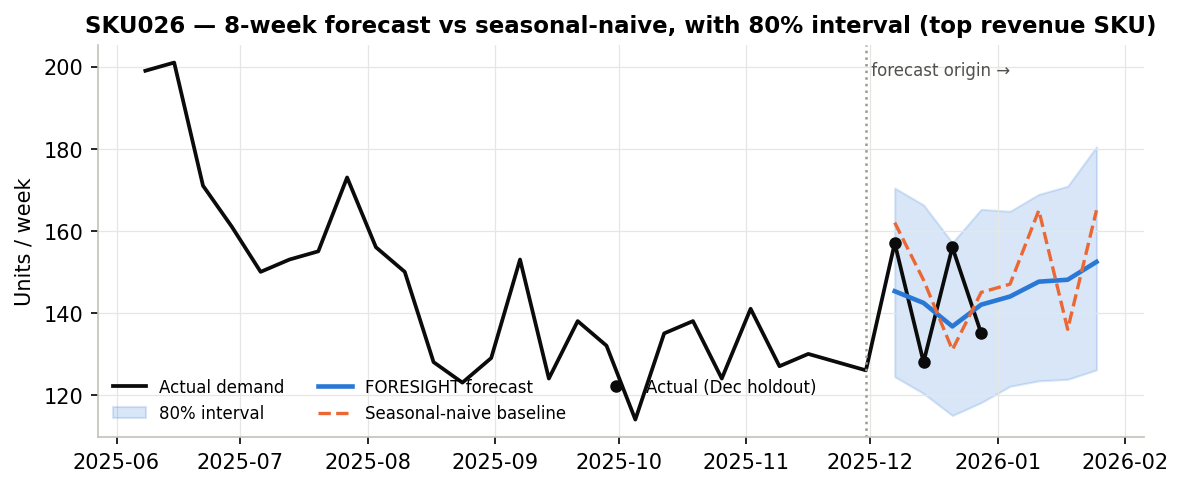

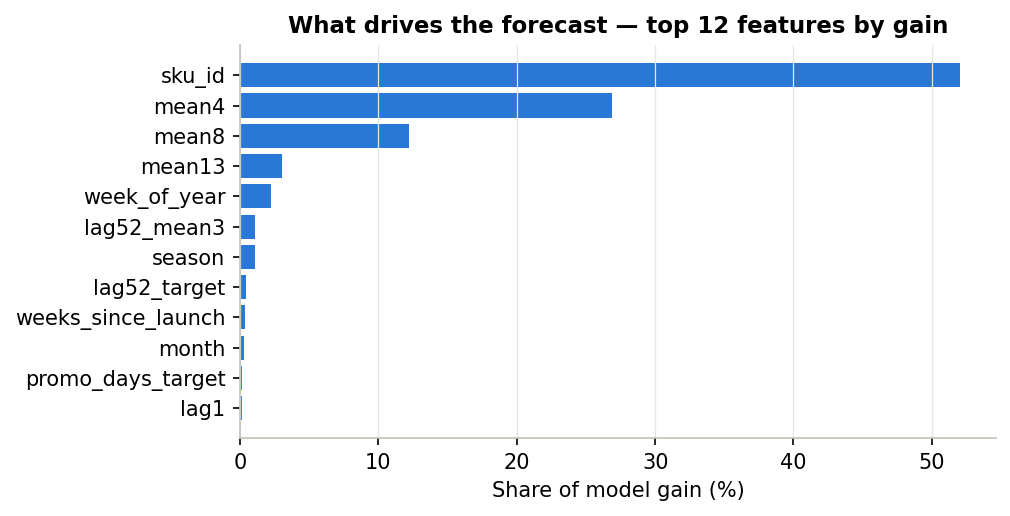

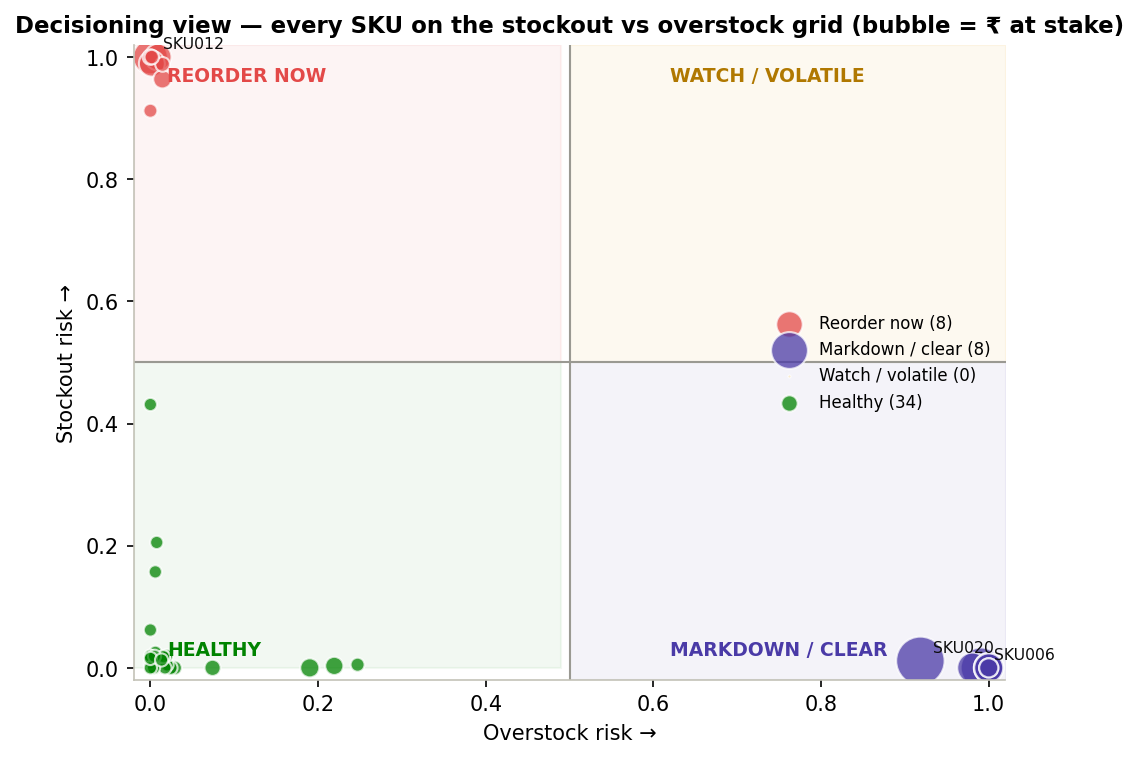

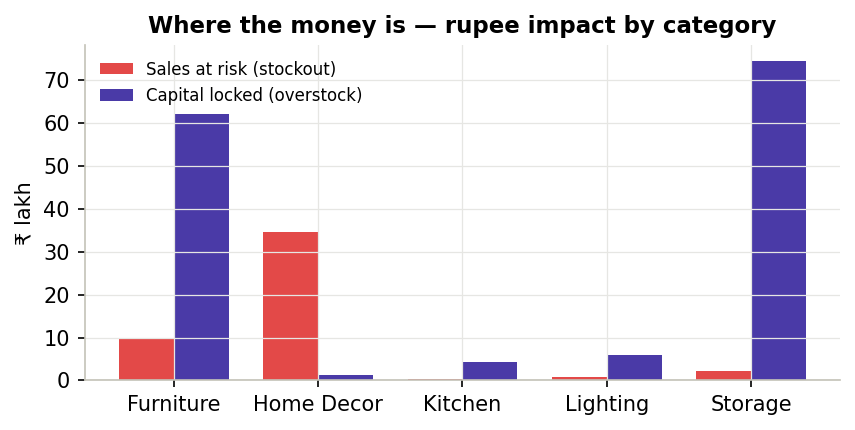

In [8]:
import eda; eda.main()
for f in ['06_backtest_wape','07_forecast_example','10_feature_importance','08_decision_grid','09_impact_by_category']:
    display(Image(str(ROOT/f'reports/figures/{f}.png'), width=900))

In [9]:
r = pd.read_csv(ROOT/'outputs/risk_scores.csv')
r[r.quadrant!='Healthy'][['priority','sku_id','category','quadrant','stockout_score','overstock_score','on_hand','on_order','demand_8w','weeks_of_cover','reorder_qty','sales_at_risk_inr','locked_capital_inr','action']]

,priority,sku_id,category,quadrant,stockout_score,overstock_score,on_hand,on_order,demand_8w,weeks_of_cover,reorder_qty,sales_at_risk_inr,locked_capital_inr,action
0,1,SKU020,Storage,Markdown / clear,0.000,0.913,1002,353,708.3,15.3,0,0.0,4332746.0,Promote or discount — 15 weeks of cover vs 8-w...
1,2,SKU006,Furniture,Markdown / clear,0.000,1.000,359,485,353.4,19.1,0,0.0,2954425.0,Promote or discount — 19 weeks of cover vs 8-w...
2,3,SKU012,Home Decor,Reorder now,1.000,0.000,47,60,1371.8,0.6,919,2054665.0,0.0,Raise a replenishment order for ~919 units bef...
3,4,SKU011,Furniture,Markdown / clear,0.000,1.000,753,269,140.3,58.3,0,0.0,1515199.0,Promote or discount — 58 weeks of cover vs 8-w...
4,5,SKU036,Furniture,Markdown / clear,0.000,1.000,383,135,255.7,16.2,0,0.0,1424428.0,Promote or discount — 16 weeks of cover vs 8-w...
5,6,SKU025,Storage,Markdown / clear,0.000,1.000,1124,61,137.2,69.1,0,0.0,1396853.0,Promote or discount — 69 weeks of cover vs 8-w...
6,7,SKU015,Storage,Markdown / clear,0.000,1.000,187,245,188.2,18.4,0,0.0,1326487.0,Promote or discount — 18 weeks of cover vs 8-w...
7,8,SKU017,Home Decor,Reorder now,1.000,0.000,95,26,706.4,1.4,506,1083202.0,0.0,Raise a replenishment order for ~506 units bef...
8,9,SKU031,Furniture,Reorder now,1.000,0.000,93,40,995.7,1.1,617,993183.0,0.0,Raise a replenishment order for ~617 units bef...
9,10,SKU004,Lighting,Markdown / clear,0.000,1.000,259,254,231.7,17.7,0,0.0,406624.0,Promote or discount — 18 weeks of cover vs 8-w...
